# Conhecendo a base

O diabetes é uma doença crônica grave na qual os indivíduos perdem a capacidade de regular efetivamente os níveis de glicose no sangue e pode levar a uma redução na qualidade de vida e na expectativa de vida.

O Sistema de Vigilância de Fatores de Risco Comportamentais (BRFSS) é uma pesquisa telefônica relacionada à saúde que é coletada anualmente pelo CDC (Centro de Controle e Prevenção de Doenças dos Estados Unidos). A cada ano, a pesquisa coleta respostas de milhares de americanos sobre comportamentos de risco relacionados à saúde, condições crônicas de saúde e o uso de serviços preventivos. Para este projeto, foi utilizado conjunto de dados disponível no Kaggle para o ano de 2015. 

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

In [24]:
from src.config import DADOS_TRATADOS

import pandas as pd

df_diabetes_tratado = pd.read_parquet(DADOS_TRATADOS)

df_diabetes_tratado.head()

,Diabetes,PressaoAlta,ColesterolAlto,ColesterolExame,IMC,Fumante,AVC,ProblemaCardiaco,AtividadeFisica,ComeFrutas,...,PlanoSaude,SemDinheiroConsultas,SaudeGeral,DiasProblemasMentais,DiasProblemasFisicos,DificuldadeAndar,Genero,FaixaIdade,Ensino,FaixaRenda
0,Não,Sim,Não,Sim,26,Não,Não,Não,Sim,Não,...,Sim,Não,Boa,5,30,Não,Masculino,35-39,Faculdade +,$75.000+
1,Não,Sim,Sim,Sim,26,Sim,Sim,Não,Não,Sim,...,Sim,Não,Boa,0,0,Não,Masculino,75-79,Faculdade +,$75.000+
2,Não,Não,Não,Sim,26,Não,Não,Não,Sim,Sim,...,Sim,Não,Excelente,0,10,Não,Masculino,80+,Faculdade +,$75.000+
3,Não,Sim,Sim,Sim,28,Sim,Não,Não,Sim,Sim,...,Sim,Não,Boa,0,3,Não,Masculino,70-74,Faculdade +,$75.000+
4,Não,Não,Não,Sim,29,Sim,Não,Não,Sim,Sim,...,Sim,Não,Muito boa,0,0,Não,Femenino,55-59,Faculdade inc. ou Técnico,$75.000+


In [25]:
colunas_numericas = df_diabetes_tratado.select_dtypes(include='number').columns.to_list()

colunas_alvo = 'Diabetes'

colunas_categoricas = df_diabetes_tratado.select_dtypes(include='category').columns.to_list()
colunas_categoricas.remove(colunas_alvo)

colunas_binarias = df_diabetes_tratado.nunique()[df_diabetes_tratado.nunique() == 2].index.to_list()
colunas_binarias.remove(colunas_alvo)

colunas_nao_binarias = list(set(colunas_categoricas) - set(colunas_binarias))


## Variáveis numéricas 

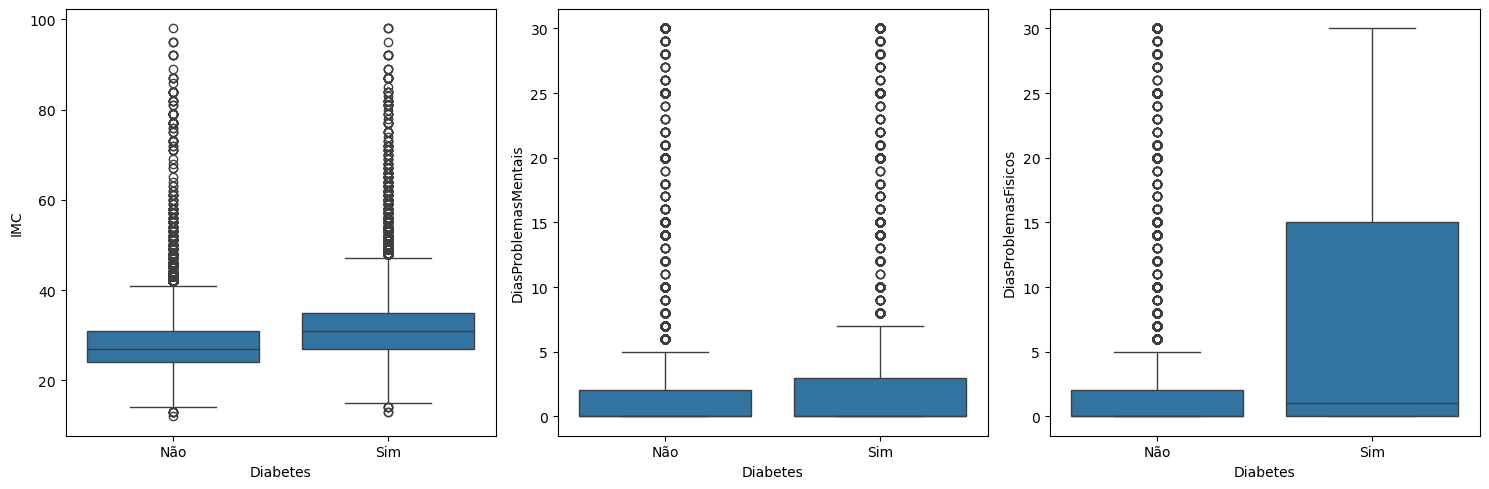

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.boxplot(data=df_diabetes_tratado, x=colunas_alvo, y=coluna, ax=ax)

plt.tight_layout()
plt.show()


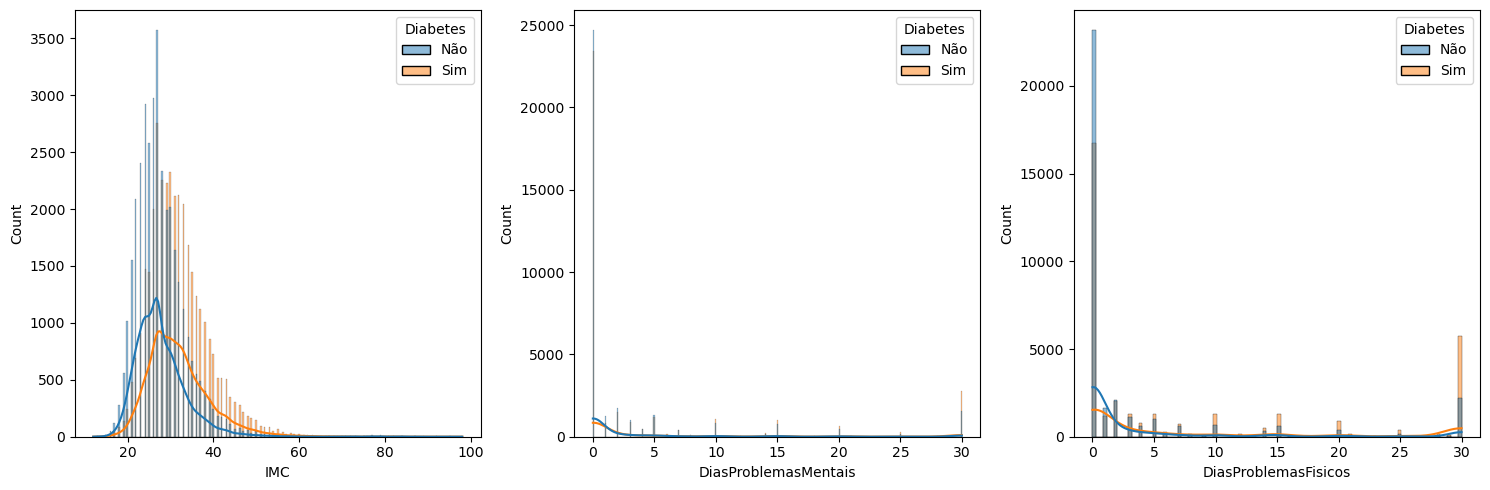

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.histplot(data=df_diabetes_tratado, x=coluna, hue=colunas_alvo, kde=True, ax=ax)

plt.tight_layout()
plt.show()

- atenção para os dados de IMC terem sido arredondados para inteiros
- será que considerar que há diferença entre diabéticos e não diabéticos considerando IMC?

In [28]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False).describe().T.round(2)

Diabetes                         Não       Sim
IMC                  count  35346.00  35346.00
                     mean      27.77     31.94
                     std        6.19      7.36
                     min       12.00     13.00
                     25%       24.00     27.00
                     50%       27.00     31.00
                     75%       31.00     35.00
                     max       98.00     98.00
DiasProblemasMentais count  35346.00  35346.00
                     mean       3.04      4.46
                     std        7.21      8.95
                     min        0.00      0.00
                     25%        0.00      0.00
                     50%        0.00      0.00
                     75%        2.00      3.00
                     max       30.00     30.00
DiasProblemasFisicos count  35346.00  35346.00
                     mean       3.67      7.95
                     std        8.10     11.30
                     min        0.00      0.00
                     25%        0.00      0.00
                     50%        0.00      1.00
                     75%        2.00     15.00
                     max       30.00     30.00

In [29]:
df_diabetes_tratado.corr(numeric_only=True)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
IMC,1.000000,0.104682,0.161862
DiasProblemasMentais,0.104682,1.000000,0.380272
DiasProblemasFisicos,0.161862,0.380272,1.000000


- teste t de Student para comparar médias de IMC entre diabéticos e não diabéticos?
- ou teste de Mann-Whitney U para comparar medianas de IMC entre diabéticos e não diabéticos?

### Faz sentido testar a normalidade das variáveis numéricas?

In [30]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False).skew(numeric_only=True)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,2.231015,2.808070,2.480202
Sim,1.527018,2.065169,1.150047


In [31]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False)[colunas_numericas].apply(pd.DataFrame.kurtosis)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,12.901012,7.012218,4.910598
Sim,5.717382,2.873176,-0.341922


In [32]:
dados_imc_sim = df_diabetes_tratado.query("Diabetes == 'Sim'")["IMC"].values

dados_imc_nao = df_diabetes_tratado.query("Diabetes == 'Não'")["IMC"].values

In [33]:
from scipy.stats import kstest, norm

print(kstest(dados_imc_nao, norm.cdf, args=(dados_imc_nao.mean(), dados_imc_nao.std())))
print(kstest(dados_imc_sim, norm.cdf, args=(dados_imc_sim.mean(), dados_imc_sim.std())))

KstestResult(statistic=0.1209153634702329, pvalue=0.0, statistic_location=28, statistic_sign=1)
KstestResult(statistic=0.10452803408478695, pvalue=0.0, statistic_location=33, statistic_sign=1)


In [34]:
dataframe_imc = pd.DataFrame({'Sim': dados_imc_sim, 'Não': dados_imc_nao})

dataframe_imc

,Sim,Não
0,30,26
1,25,26
2,28,26
3,23,28
4,27,29
...,...,...
35341,37,23
35342,29,29
35343,25,24
35344,18,53


In [35]:
from src.auxiliares import analise_levene

analise_levene(dataframe_imc, centro='median')

Teste de Levene
estatistica_levene=888.297
Ao menos uma variância é diferente (valor p: 0.000)


In [36]:
from src.auxiliares import analise_ttest_ind, analise_mannwhitneyu

analise_ttest_ind(dataframe_imc, variancias_iguais=False)

Teste t de Student
estatistica_ttest=81.591
Rejeita a hipótese nula (valor p: 0.000)


In [37]:
analise_mannwhitneyu(dataframe_imc)

Teste de Mann-Whitney
estatistica_mw=861173484.000
Rejeita a hipótese nula (valor p: 0.000)


## Os outliers interferem ?

In [38]:
def remove_outliers(dados, bigode=1.5):
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    return dados[(dados >= q1 - bigode * iqr) & (dados <= q3 + bigode * iqr)]

In [39]:
df_diabetes_sem_outliers = df_diabetes_tratado.copy()

for coluna in colunas_numericas:
    df_diabetes_sem_outliers[coluna] = remove_outliers(df_diabetes_sem_outliers[coluna])

df_diabetes_sem_outliers.describe()

,IMC,DiasProblemasMentais,DiasProblemasFisicos
count,68511.000000,58876.000000,60068.000000
mean,29.129673,0.526615,1.880619
std,5.695466,1.271375,3.727202
min,13.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000
50%,28.000000,0.000000,0.000000
75%,33.000000,0.000000,2.000000
max,45.000000,5.000000,15.000000


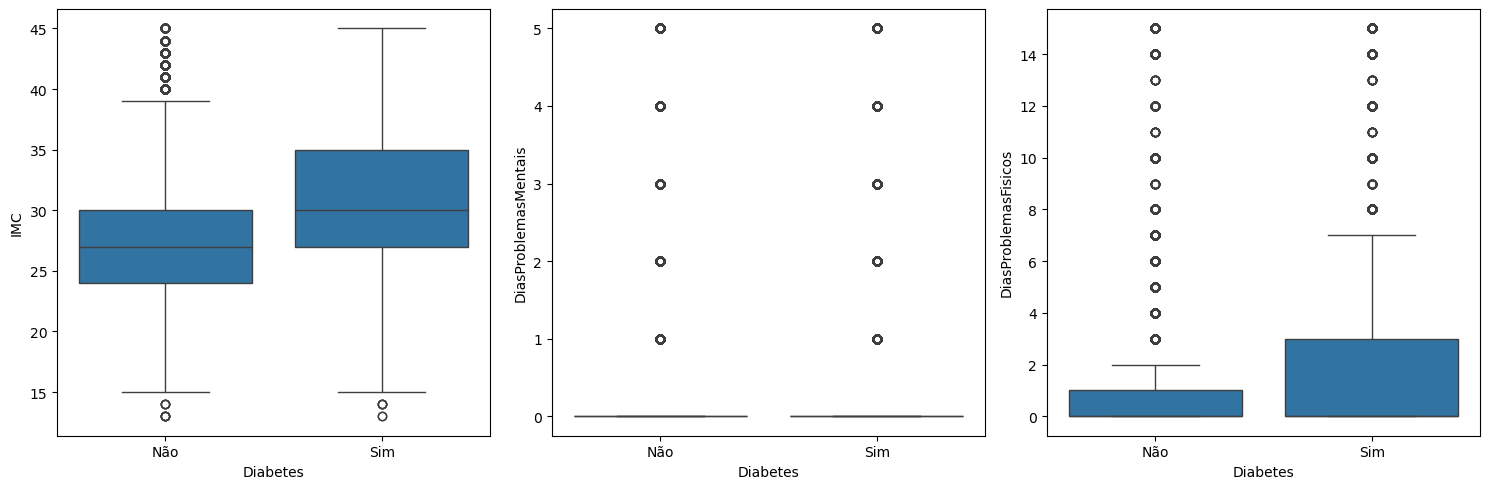

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.boxplot(data=df_diabetes_sem_outliers, x=colunas_alvo, y=coluna, ax=ax)

plt.tight_layout()
plt.show()

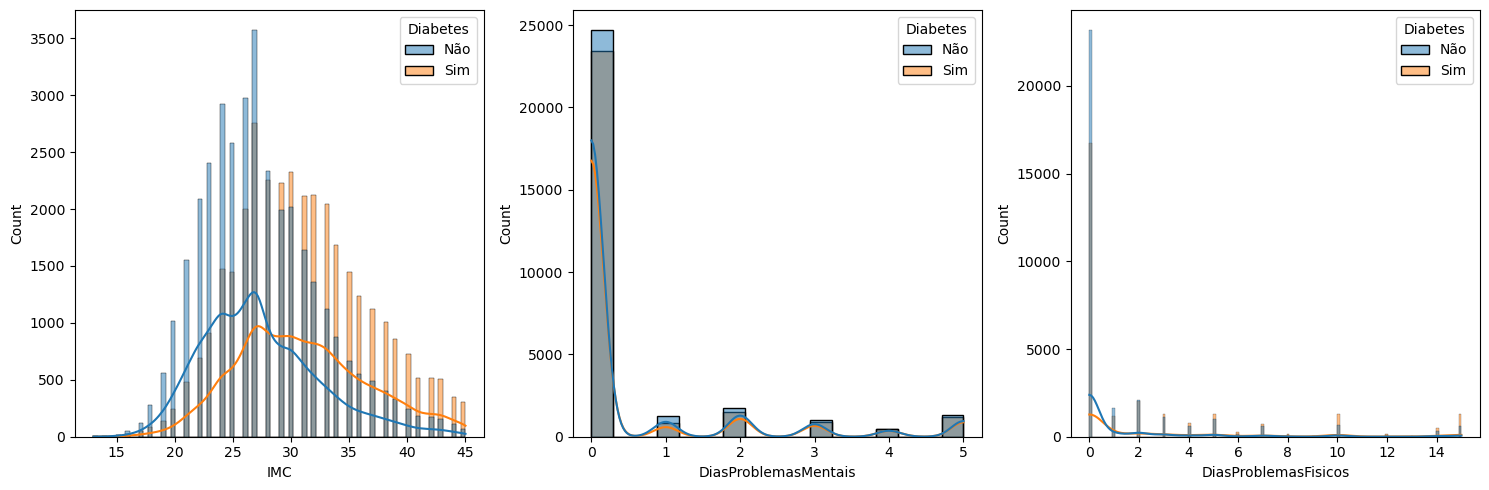

In [41]:
fig, axs = plt.subplots(1,3, figsize=(15,5)) 

for ax, coluna in zip(axs, colunas_numericas):
    sns.histplot(data=df_diabetes_sem_outliers, x=coluna, hue=colunas_alvo, kde=True, ax=ax)

plt.tight_layout()
plt.show()

In [42]:
dados_imc_sim_sem_outliers = df_diabetes_sem_outliers.query('Diabetes == "Sim"')['IMC'].values

dados_imc_nao_sem_outliers = df_diabetes_sem_outliers.query('Diabetes == "Não"')['IMC'].values

dataframe_imc_sem_outliers = pd.DataFrame({'Sim': dados_imc_sim_sem_outliers, 'Não': dados_imc_nao_sem_outliers})
dataframe_imc_sem_outliers


,Sim,Não
0,30.0,26.0
1,25.0,26.0
2,28.0,26.0
3,23.0,28.0
4,27.0,29.0
...,...,...
35341,37.0,23.0
35342,29.0,29.0
35343,25.0,24.0
35344,18.0,NaN


In [43]:
from scipy.stats import kstest, norm

print(kstest(dados_imc_nao_sem_outliers, norm.cdf, args=(dados_imc_nao_sem_outliers.mean(), dados_imc_nao_sem_outliers.std()), nan_policy='omit'))
print(kstest(dados_imc_sim_sem_outliers, norm.cdf, args=(dados_imc_sim_sem_outliers.mean(), dados_imc_sim_sem_outliers.std()), nan_policy='omit'))

KstestResult(statistic=nan, pvalue=nan, statistic_location=13.0, statistic_sign=-1)
KstestResult(statistic=nan, pvalue=nan, statistic_location=13.0, statistic_sign=-1)


In [44]:
print(
    kstest(
        dataframe_imc_sem_outliers['Não'], 
        norm.cdf, 
        args=(dataframe_imc_sem_outliers['Não'].mean(), 
              dataframe_imc_sem_outliers['Não'].std()), 
        nan_policy='omit')
)

print(
    kstest(
        dataframe_imc_sem_outliers['Sim'], 
        norm.cdf, 
        args=(dataframe_imc_sem_outliers['Sim'].mean(), 
              dataframe_imc_sem_outliers['Sim'].std()), 
        nan_policy='omit')
)

KstestResult(statistic=0.10815079726309146, pvalue=0.0, statistic_location=27.0, statistic_sign=1)
KstestResult(statistic=0.07345716240963396, pvalue=2.3370072025339465e-158, statistic_location=30.0, statistic_sign=1)


In [45]:
analise_levene(dataframe_imc_sem_outliers, centro='median')

Teste de Levene
estatistica_levene=532.986
Ao menos uma variância é diferente (valor p: 0.000)


In [46]:
analise_ttest_ind(dataframe_imc_sem_outliers, variancias_iguais=False)

Teste t de Student
estatistica_ttest=85.248
Rejeita a hipótese nula (valor p: 0.000)


In [47]:
analise_mannwhitneyu(dataframe_imc_sem_outliers)

Teste de Mann-Whitney
estatistica_mw=801702843.000
Rejeita a hipótese nula (valor p: 0.000)


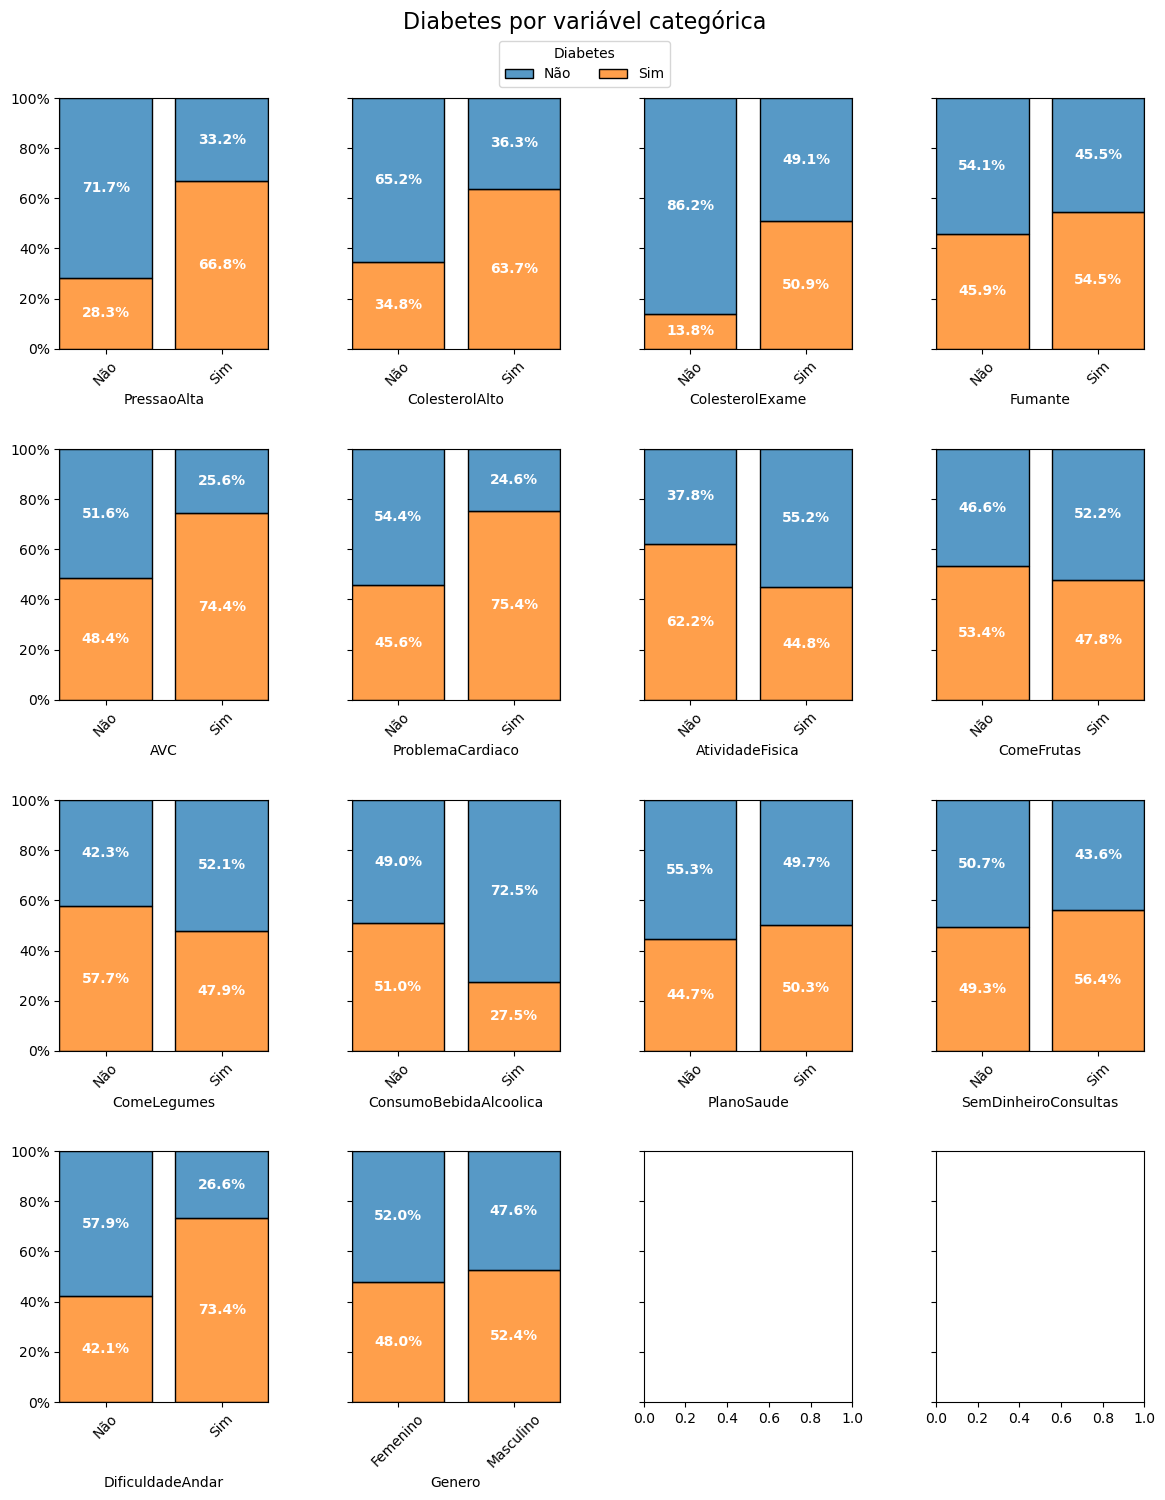

In [48]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 16), sharey=True)

for i, coluna in enumerate(colunas_binarias):
    h = sns.histplot(x=coluna,
                     hue=colunas_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.4, hspace=0.4, top=0.925)

plt.show()

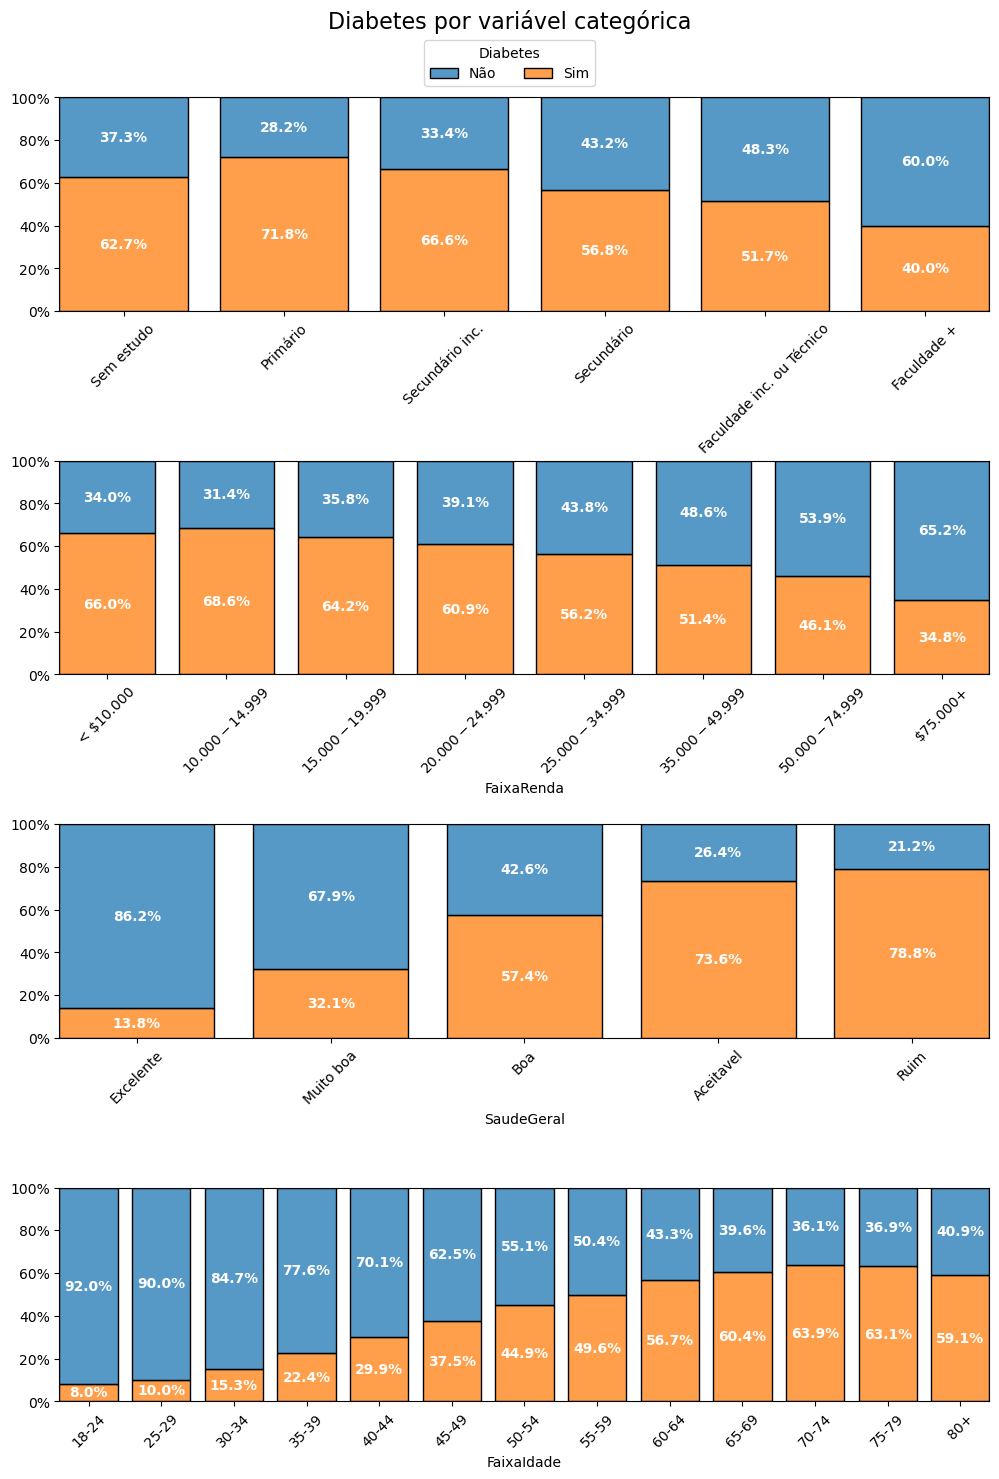

In [49]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 16))

for i, coluna in enumerate(colunas_nao_binarias):
    h = sns.histplot(x=coluna,
                     hue=colunas_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.1, hspace=0.7, top=0.925)

plt.show()

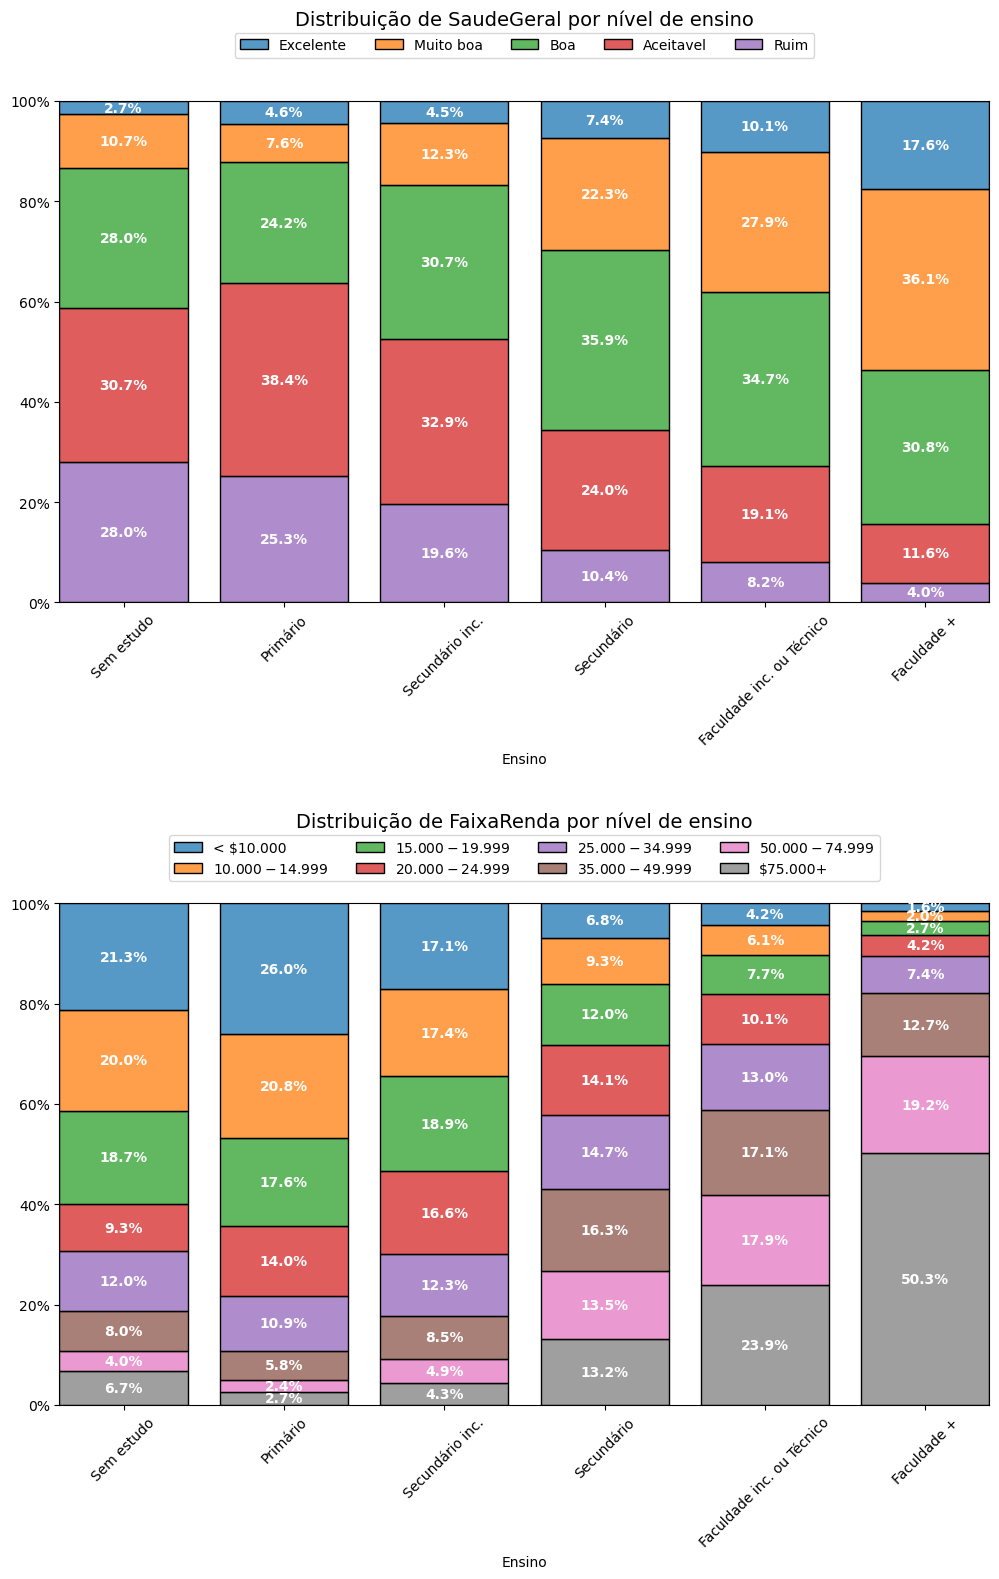

In [50]:
colunas_analise = ["SaudeGeral", "FaixaRenda"]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 16))

for ax, coluna in zip(axs.flatten(), colunas_analise):
    h = sns.histplot(x="Ensino",
                     hue=coluna,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=ax,
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()

    labels = [text.get_text() for text in legend.get_texts()]

    numero_itens = len(df_diabetes_tratado[coluna].cat.categories)

    ax.legend(
        handles=legend.legend_handles,
        labels=labels,
        loc="upper center",
        ncols=numero_itens if numero_itens <= 6 else min(4, numero_itens),
        bbox_to_anchor=(0.5, 1.15),
    )

    ax.set_title(f"Distribuição de {coluna} por nível de ensino", fontsize=14, pad=55)

plt.subplots_adjust(wspace=0.1, hspace=0.6, top=0.925)

plt.show()

In [51]:
tabela_contigencia = {}

for coluna in df_diabetes_tratado.select_dtypes('category').columns:
    if coluna != colunas_alvo:
        tabela_contigencia[coluna] = pd.crosstab(df_diabetes_tratado[colunas_alvo], df_diabetes_tratado[coluna])

tabela_contigencia['PressaoAlta']

PressaoAlta,Não,Sim
Diabetes,,
Não,22118,13228
Sim,8742,26604


In [52]:

for coluna in df_diabetes_tratado.select_dtypes('category').columns:
    if coluna != colunas_alvo:
        display(
            pd.crosstab(
                df_diabetes_tratado[colunas_alvo],
                df_diabetes_tratado[coluna],
                margins=True,
                normalize='index'
            ).style.format('{:.2%}'))

PressaoAlta,Não,Sim
Diabetes,,
Não,62.58%,37.42%
Sim,24.73%,75.27%
All,43.65%,56.35%


ColesterolAlto,Não,Sim
Diabetes,,
Não,61.87%,38.13%
Sim,32.99%,67.01%
All,47.43%,52.57%


ColesterolExame,Não,Sim
Diabetes,,
Não,4.27%,95.73%
Sim,0.68%,99.32%
All,2.47%,97.53%


Fumante,Não,Sim
Diabetes,,
Não,56.77%,43.23%
Sim,48.18%,51.82%
All,52.47%,47.53%


AVC,Não,Sim
Diabetes,,
Não,96.81%,3.19%
Sim,90.75%,9.25%
All,93.78%,6.22%


...

DificuldadeAndar,Não,Sim
Diabetes,,
Não,86.58%,13.42%
Sim,62.88%,37.12%
All,74.73%,25.27%


Genero,Femenino,Masculino
Diabetes,,
Não,56.51%,43.49%
Sim,52.09%,47.91%
All,54.30%,45.70%


FaixaIdade,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80+
Diabetes,,,,,,,,,,,,,
Não,2.55%,3.55%,4.91%,6.13%,6.99%,8.22%,10.71%,12.28%,12.39%,12.16%,8.21%,5.63%,6.27%
Sim,0.22%,0.40%,0.89%,1.77%,2.97%,4.93%,8.74%,12.06%,16.22%,18.55%,14.54%,9.63%,9.08%
All,1.38%,1.97%,2.90%,3.95%,4.98%,6.58%,9.72%,12.17%,14.30%,15.36%,11.38%,7.63%,7.68%


Ensino,Sem estudo,Primário,Secundário inc.,Secundário,Faculdade inc. ou Técnico,Faculdade +
Diabetes,,,,,,
Não,0.08%,1.31%,3.26%,23.78%,27.38%,44.19%
Sim,0.13%,3.35%,6.50%,31.31%,29.29%,29.42%
All,0.11%,2.33%,4.88%,27.55%,28.33%,36.81%


FaixaRenda,< $10.000,$10.000-$14.999,$15.000-$19.999,$20.000-$24.999,$25.000-$34.999,$35.000-$49.999,$50.000-$74.999,$75.000+
Diabetes,,,,,,,,
Não,3.47%,3.99%,5.63%,7.37%,9.92%,14.13%,17.43%,38.06%
Sim,6.74%,8.73%,10.09%,11.47%,12.74%,14.97%,14.90%,20.36%
All,5.11%,6.36%,7.86%,9.42%,11.33%,14.55%,16.16%,29.21%
